In [34]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [35]:
df=pd.read_csv('clustring.csv')
df

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,2008,F,16.329,21,0,0,0,0,0,0,...,0,0,0,2,0,0,0,1,0,0
14996,2008,F,16.545,50,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
14997,2007,F,17.999,32,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14998,2007,F,17.903,20,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
df.columns

Index(['gradyear', 'gender', 'age', 'NumberOffriends', 'basketball',
       'football', 'soccer', 'softball', 'volleyball', 'swimming',
       'cheerleading', 'baseball', 'tennis', 'sports', 'cute', 'sex', 'sexy',
       'hot', 'kissed', 'dance', 'band', 'marching', 'music', 'rock', 'god',
       'church', 'jesus', 'bible', 'hair', 'dress', 'blonde', 'mall',
       'shopping', 'clothes', 'hollister', 'abercrombie', 'die', 'death',
       'drunk', 'drugs'],
      dtype='object')

In [37]:
selected_features = ['gradyear', 'gender', 'age', 'NumberOffriends', 'basketball',
       'football', 'soccer', 'softball', 'volleyball', 'swimming',]

X = df[selected_features]

In [38]:
df.isnull().sum()

gradyear              0
gender             1337
age                2496
NumberOffriends       0
basketball            0
football              0
soccer                0
softball              0
volleyball            0
swimming              0
cheerleading          0
baseball              0
tennis                0
sports                0
cute                  0
sex                   0
sexy                  0
hot                   0
kissed                0
dance                 0
band                  0
marching              0
music                 0
rock                  0
god                   0
church                0
jesus                 0
bible                 0
hair                  0
dress                 0
blonde                0
mall                  0
shopping              0
clothes               0
hollister             0
abercrombie           0
die                   0
death                 0
drunk                 0
drugs                 0
dtype: int64

In [39]:
df['gender'] = df['gender'].fillna('U')
df['gender'].value_counts(dropna=False)

gender
F    11057
M     2606
U     1337
Name: count, dtype: int64

In [40]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age'].value_counts(dropna=False)
df.groupby('gradyear')['age'].mean()

gradyear
2006    19.010786
2007    18.400134
2008    17.593006
2009    16.886244
Name: age, dtype: float64

In [41]:
df['age'] = df.groupby('gradyear')['age'].transform(lambda x: x.fillna(x.mean()))
df['age'].value_counts(dropna=False)

age
16.886244     765
17.593006     709
18.400134     667
19.010786     631
17.399000      20
             ... 
51.619000       1
19.874000       1
19.967000       1
106.294000      1
56.775000       1
Name: count, Length: 1877, dtype: int64

In [42]:
df.age.describe()

count    15000.000000
mean        17.974626
std          6.975129
min          4.309000
25%         16.545000
50%         17.466000
75%         18.400134
max        106.927000
Name: age, dtype: float64

In [43]:
categorical_features = ['gender']

# One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_features)
X_encoded.head()

,gradyear,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,gender_F,gender_M
0,2007,NaN,0,0,0,0,0,0,0,False,False
1,2007,17.41,49,0,0,1,0,0,1,True,False
2,2007,17.511,41,0,0,0,0,0,0,True,False
3,2006,NaN,36,0,0,0,0,0,0,True,False
4,2008,16.657,1,0,0,0,0,0,1,True,False


In [44]:
X_encoded = pd.get_dummies(X, columns=['gender'])

X_encoded

,gradyear,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,gender_F,gender_M
0,2007,NaN,0,0,0,0,0,0,0,False,False
1,2007,17.41,49,0,0,1,0,0,1,True,False
2,2007,17.511,41,0,0,0,0,0,0,True,False
3,2006,NaN,36,0,0,0,0,0,0,True,False
4,2008,16.657,1,0,0,0,0,0,1,True,False
...,...,...,...,...,...,...,...,...,...,...,...
14995,2008,16.329,21,0,0,0,0,0,0,True,False
14996,2008,16.545,50,0,0,0,0,0,0,True,False
14997,2007,17.999,32,0,0,0,0,0,0,True,False
14998,2007,17.903,20,0,0,0,0,0,0,True,False


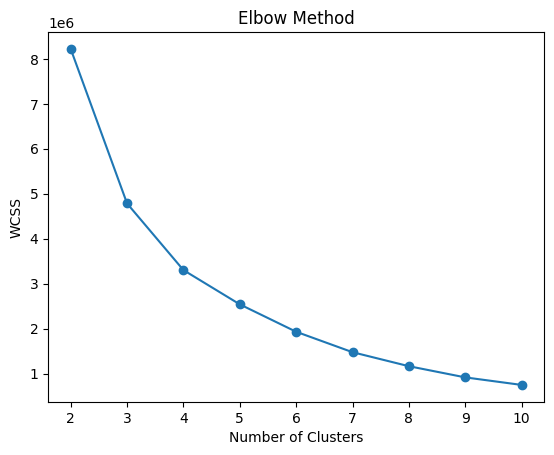

In [45]:

categorical_features = ['gender']  

X_encoded = pd.get_dummies(df[selected_features + categorical_features])

wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
    kmeans.fit(X_encoded)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


Best K (Elbow): 4


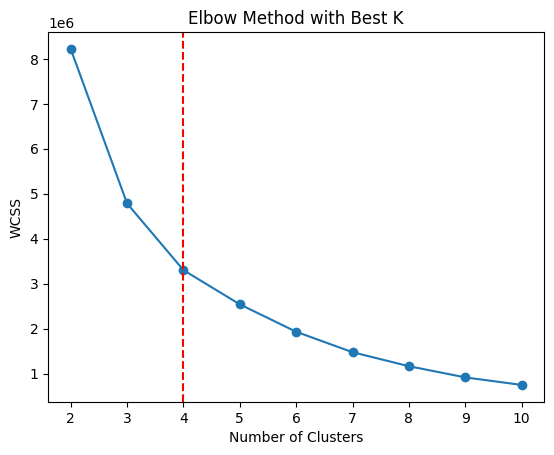

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Example: WCSS from your previous K-Means
x = np.arange(2, 11)       # K values
y = np.array(wcss)         # WCSS values

# Line between first and last point
line = np.polyfit([x[0], x[-1]], [y[0], y[-1]], 1)
y_line = np.polyval(line, x)

# Distance from each point to the line
distances = np.abs(y - y_line)
best_k = x[np.argmax(distances)]
print("Best K (Elbow):", best_k)

# Plot
plt.plot(x, y, marker='o')
plt.axvline(best_k, linestyle='--', color='r')
plt.title('Elbow Method with Best K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [47]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Example: use only 'basketball' and 'football' features
X_features = X_encoded[['basketball', 'football']]

# Fit KMeans
kmeans = KMeans(n_clusters=2, random_state=42)  # choose n_clusters as needed
kmeans.fit(X_features)

# Get cluster labels
clusters = kmeans.labels_

# Compute silhouette score
score = silhouette_score(X_features, clusters)
print("Silhouette Score:", score)


Silhouette Score: 0.7707450592820858


In [70]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.20042506 0.12051976]


In [71]:
# Run KMeans
k = 4
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Add cluster labels to the dataframe
X_encoded['Cluster'] = clusters

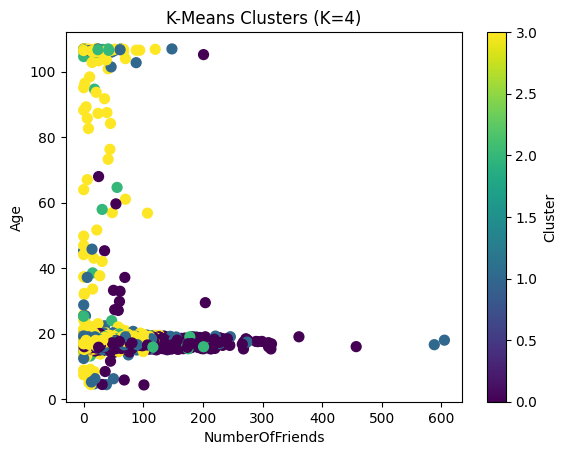

In [72]:
labels = kmeans.labels_  # Cluster labels for each point
#print(labels)

# Plot with colors based on clusters
plt.scatter(
    X_encoded["NumberOffriends"],
    X_encoded["age"],
    c=labels,  # color by cluster
    cmap='viridis',  # you can change colormap
    s=50,
    marker='o'
)

plt.title('K-Means Clusters (K=4)')
plt.xlabel('NumberOfFriends')
plt.ylabel('Age')
plt.colorbar(label='Cluster')  # optional: show cluster color scale
plt.show()


In [74]:
X_pca

array([[-3.09748387,  4.33853398],
       [ 1.20335168, -0.09210978],
       [ 1.09434281, -0.04431604],
       ...,
       [ 1.07427425, -0.03931353],
       [ 0.89828342,  0.02556789],
       [ 1.49420963, -0.26826535]], shape=(15000, 2))

In [75]:
X_encoded["Cluster"].unique()

array([2, 3, 1, 0], dtype=int32)

In [77]:
score = silhouette_score(X_pca, clusters)
print("Silhouette Score:", score)


Silhouette Score: 0.9360520637375613


In [90]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


X_features = X_pca

# Fit KMeans
kmeans = KMeans(n_clusters=2, random_state=42)  # choose n_clusters as needed
kmeans.fit(X_features)

# Get cluster labels
clusters = kmeans.labels_

# Compute silhouette score
score = silhouette_score(X_pca, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.7750193099750748


In [92]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.20042506 0.12051976]


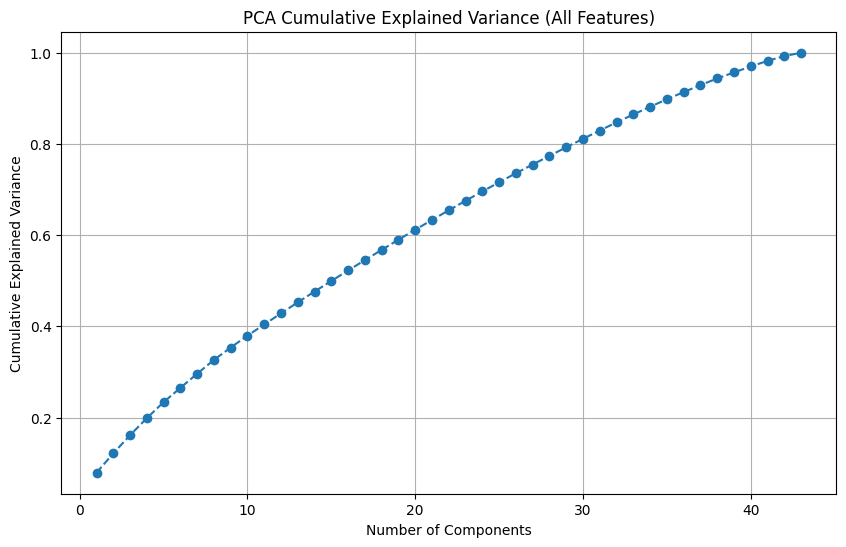

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance (All Features)')
plt.grid(True)
plt.show()
